# Anticonformity time trajectories 

This notebook reproduces the trajectory panels from `time_trajectories_framing_1.ipynb` for the `verB` simulation files. The line is the trajectory percentage and the shaded band is the corresponding standard deviation read from the matching `noise_anticonformity_*` file. The plots are limited to rounds 0–20.

The input matrices are tab-separated, have three rows (`+1`, `0`, `-1`), and columns for rounds 0–1000. `crossfaction=True` is mapped to `beta=0.5`; `crossfaction=False` is mapped to `beta=0`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

DATA_DIR = Path('raw_simulations_data')
OUTPUT_DIR = DATA_DIR
RESPONSE_LEVELS = [1, 0, -1]
BETA_LEVELS = [0.0, 0.5]
P_ANTI_LEVELS = [0.0, 0.5, 1.0]
PLOT_ROUND_MAX = 20

COLORS = {1: '#7b3294', 0: '#000000', -1: '#008837'}
LABELS = {1: '+1 (For)', 0: '0 (Neutral)', -1: '−1 (Against)'}
LINE_STYLES = {1: '-.', 0: '-', -1: '--'}

def read_matrix(path, value_name):
    matrix = pd.read_csv(path, sep='\t', header=None)
    if matrix.shape[0] != len(RESPONSE_LEVELS):
        raise ValueError(f'{path.name} must have exactly three rows.')
    if matrix.empty or matrix.isna().any().any():
        raise ValueError(f'{path.name} is empty or contains missing values.')
    matrix = matrix.apply(pd.to_numeric)
    n_rounds = matrix.shape[1]
    return pd.DataFrame({
        'round_no': np.tile(np.arange(n_rounds), len(RESPONSE_LEVELS)),
        'response': np.repeat(RESPONSE_LEVELS, n_rounds),
        value_name: matrix.to_numpy(dtype=float).reshape(-1),
    })

def parse_condition_name(name):
    parts = Path(name).stem.split('_')
    if (len(parts) != 7 or parts[:2] != ['trajectory', 'anticonformity']
            or parts[3] != 'political' or parts[5] != 'crossfaction'
            or parts[4] not in {'true', 'false'}
            or parts[6] not in {'true', 'false'}):
        raise ValueError(f'Unexpected trajectory filename: {name}')
    return float(parts[2]), parts[4] == 'true', 0.5 if parts[6] == 'true' else 0.0

def load_data():
    records = []
    trajectory_paths = sorted(DATA_DIR.glob('trajectory_anticonformity_*.csv'))
    if not trajectory_paths:
        raise FileNotFoundError(f'No trajectory files found in {DATA_DIR.resolve()}')

    for trajectory_path in trajectory_paths:
        p_anti, political, beta = parse_condition_name(trajectory_path.name)
        noise_path = DATA_DIR / trajectory_path.name.replace(
            'trajectory_anticonformity_', 'noise_anticonformity_', 1
        )
        if not noise_path.exists():
            raise FileNotFoundError(f'Missing matching noise file: {noise_path.name}')

        trajectory = read_matrix(trajectory_path, 'mean_percent')
        noise = read_matrix(noise_path, 'std_percent')
        condition = trajectory.merge(noise, on=['round_no', 'response'], how='outer')
        if condition[['mean_percent', 'std_percent']].isna().any().any():
            raise ValueError(f'Round/response grids do not match for {trajectory_path.name}.')
        condition['p_anti'] = p_anti
        condition['political'] = political
        condition['beta'] = beta
        records.append(condition)

    data = pd.concat(records, ignore_index=True)
    if len(records) != len(P_ANTI_LEVELS) * len(BETA_LEVELS) * 2:
        raise ValueError('The expected 12 trajectory/noise conditions were not found.')
    if (data['mean_percent'] < 0).any() or (data['mean_percent'] > 100).any():
        raise ValueError('Trajectory percentages must be between 0 and 100.')
    if (data['std_percent'] < 0).any():
        raise ValueError('Standard deviations must be non-negative.')
    return data


In [2]:
def spread_annotation_positions(values, min_gap=8.5, lower=5.5, upper=94.5):
    ordered = sorted(values, key=values.get)
    positions = {response: max(lower, min(upper, values[response])) for response in ordered}
    for previous, current in zip(ordered, ordered[1:]):
        positions[current] = max(positions[current], positions[previous] + min_gap)
    overflow = positions[ordered[-1]] - upper
    if overflow > 0:
        positions = {response: position - overflow for response, position in positions.items()}
    underflow = lower - positions[ordered[0]]
    if underflow > 0:
        positions = {response: position + underflow for response, position in positions.items()}
    return positions

def plot_framing(data, political, output_path):
    framing_data = data.loc[
        (data['political'] == political) & (data['round_no'] <= PLOT_ROUND_MAX)
    ]
    round_min = int(framing_data['round_no'].min())
    round_max = min(int(framing_data['round_no'].max()), PLOT_ROUND_MAX)
    annotation_round = round_max

    plt.rcParams.update({
        'font.size': 15, 'axes.labelsize': 19,
        'xtick.labelsize': 15, 'ytick.labelsize': 15, 'legend.fontsize': 15,
    })
    fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)

    for row, beta in enumerate(BETA_LEVELS):
        for col, p_anti in enumerate(P_ANTI_LEVELS):
            ax = axes[row, col]
            panel = framing_data.loc[
                (framing_data['beta'] == beta) & (framing_data['p_anti'] == p_anti)
            ]
            trajectories = {}

            for response in RESPONSE_LEVELS:
                trajectory = panel.loc[panel['response'] == response].sort_values('round_no')
                if len(trajectory) != round_max - round_min + 1:
                    raise ValueError(f'Incomplete trajectory in panel {beta=}, {p_anti=}, {response=}.')
                trajectories[response] = trajectory
                x = trajectory['round_no'].to_numpy()
                mean = trajectory['mean_percent'].to_numpy()
                std = trajectory['std_percent'].to_numpy()
                lower = np.clip(mean - std, 0, 100)
                upper = np.clip(mean + std, 0, 100)
                ax.fill_between(x, lower, upper, color=COLORS[response], alpha=0.18, linewidth=0)
                ax.plot(x, mean, color=COLORS[response], linewidth=2, linestyle=LINE_STYLES[response])

            values = {
                response: trajectories[response].loc[
                    trajectories[response]['round_no'] == annotation_round, 'mean_percent'
                ].iloc[0]
                for response in RESPONSE_LEVELS
            }
            label_positions = spread_annotation_positions(values)
            for response in RESPONSE_LEVELS:
                ax.annotate(
                    f'{values[response]:.0f}',
                    xy=(annotation_round, values[response]),
                    xytext=(annotation_round - 0.25, label_positions[response]),
                    color=COLORS[response], fontsize=13, fontweight='bold',
                    ha='right', va='center', clip_on=True, zorder=5,
                    bbox=dict(boxstyle='round,pad=0.12', facecolor='white', edgecolor='none', alpha=0.82),
                    arrowprops=dict(arrowstyle='-', color=COLORS[response], linewidth=0.7, alpha=0.8, shrinkA=1, shrinkB=1),
                )

            if row == 0:
                ax.set_title(f'p = {p_anti:.1f}', fontsize=16, pad=12)
            panel_label = chr(ord('a') + row * len(P_ANTI_LEVELS) + col)
            ax.text(0.03, 0.97, f'({panel_label})', transform=ax.transAxes, ha='left', va='top', fontsize=16)
            ax.set_xlim(round_min, round_max)
            ax.set_ylim(0, 100)
            ax.set_yticks([0, 50, 100], ['0', '50', '100'])
            ax.set_xticks(range(round_min, round_max + 1, 5))
            ax.axhline(50, color='0.75', linewidth=0.8, zorder=0)
            ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
            for spine in ax.spines.values():
                spine.set_visible(True)
            if col == len(P_ANTI_LEVELS) - 1:
                ax.text(1.08, 0.5, rf'$\beta = {beta:g}$', transform=ax.transAxes, rotation=270, va='center', ha='center', fontsize=16)

    legend_order = [1, 0, -1]
    legend_handles = [
        Line2D([0], [0], color=COLORS[response], linewidth=2, linestyle=LINE_STYLES[response], label=LABELS[response])
        for response in legend_order
    ]
    legend_handles.append(Patch(facecolor='0.5', alpha=0.18, edgecolor='none', label='Standard deviation (± 1 SD)'))
    fig.legend(handles=legend_handles, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.07))
    fig.supxlabel('Round', fontsize=19, y=0.15)
    fig.supylabel('Belief in the neighborhood (%)', fontsize=19, x=0.045)
    fig.tight_layout(rect=(0.04, 0.12, 0.97, 0.98))
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)


Loaded 36,036 rows for 12 conditions and rounds 0–1000.


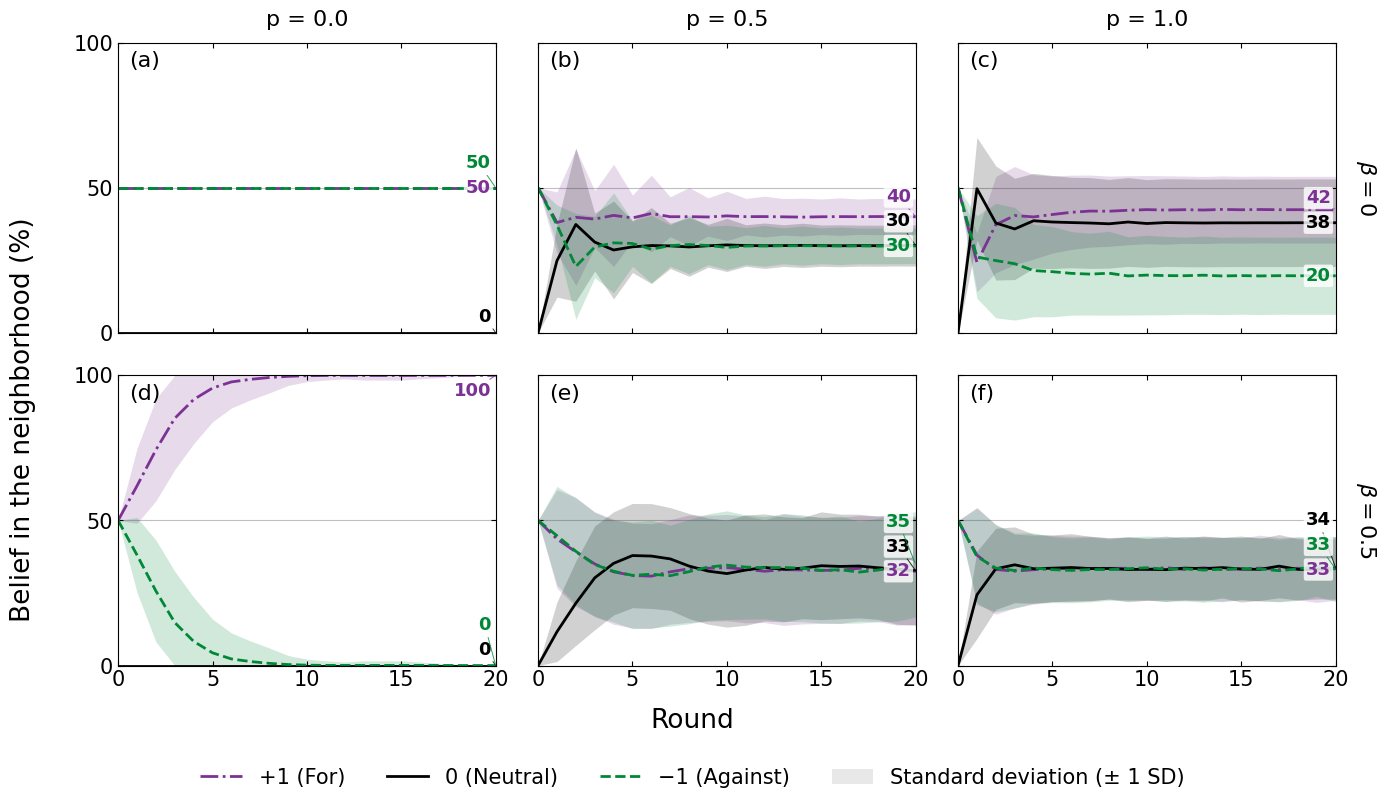

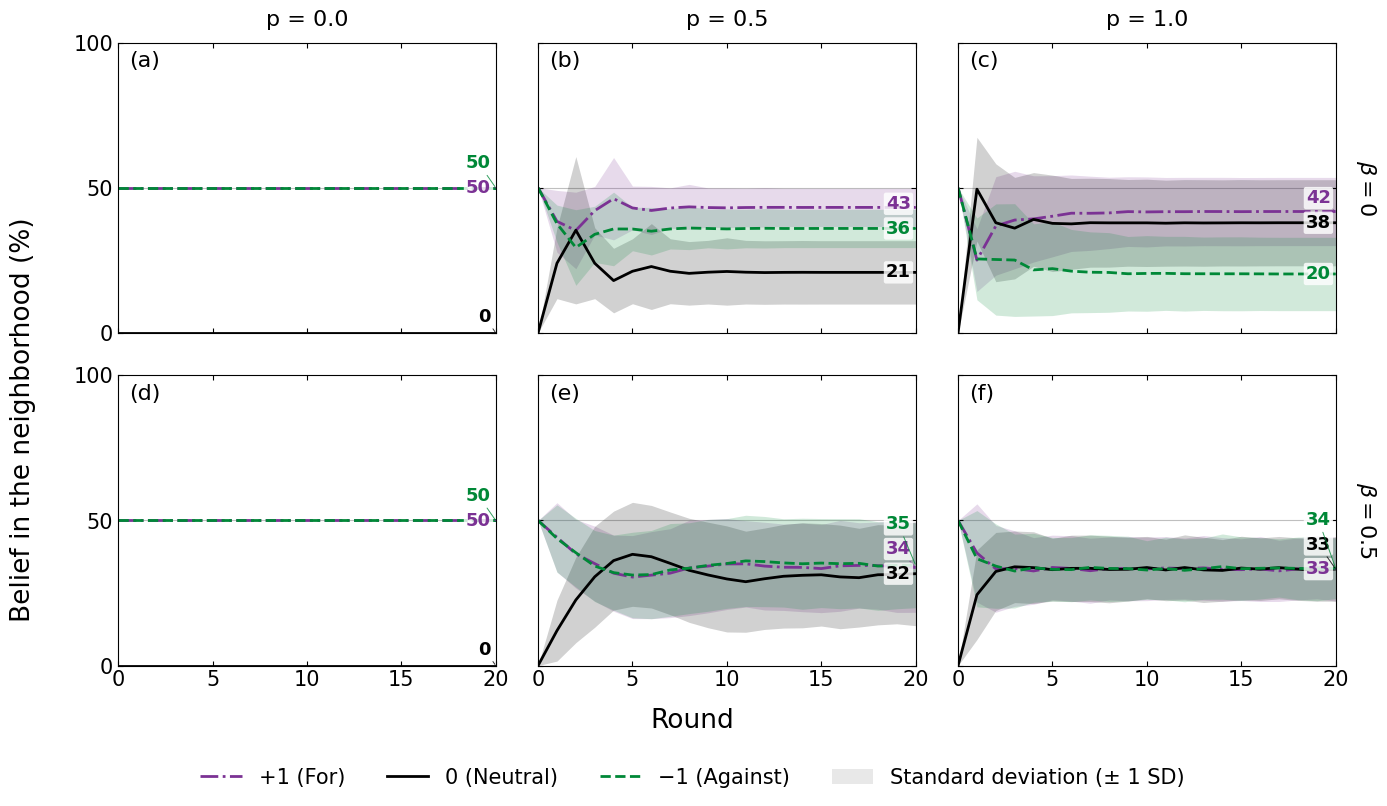

In [3]:
data = load_data()
print(f'Loaded {len(data):,} rows for 12 conditions and rounds {int(data.round_no.min())}–{int(data.round_no.max())}.')

plot_framing(data, False, 'trajectory_nonpolitical_simulations.png')
plot_framing(data, True,  'trajectory_political_simulations.png')